In [2]:
from google.colab import files

uploaded = files.upload()  # Upload your Resume.zip

Saving Resume.zip to Resume.zip


In [3]:
import zipfile

zip_path = "Resume.zip"
extract_path = "resumes"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [4]:
!pip install pdfplumber python-docx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.1 MB/s eta 0:00:00


In [5]:
import os
import pandas as pd
import pdfplumber
from docx import Document



def read_pdf(file_path):
    text = ""
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    return text

from docx import Document

def read_docx(file_path):
    doc = Document(file_path)
    return " ".join([para.text for para in doc.paragraphs])

In [8]:
!ls resumes #The ! at the beginning indicates that it's a shell command.


__MACOSX  Resumes


In [9]:
!ls resumes/Resumes


 Internship	    'React JS Developer'  'workday '
'Peoplesoft Admin'  'SQL Developer'


In [12]:
import os
import pandas as pd

data = []

base_dir = "resumes/Resumes"

for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)

    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            file_path = os.path.join(category_path, file)
            file_lower = file.lower()

            if file_lower.endswith(".pdf"):
                text = read_pdf(file_path)

            elif file_lower.endswith(".docx"):
                text = read_docx(file_path)

            else:
                continue  # skip non-resume files

            if text and text.strip():  # safety check
                data.append({
                    "text": text,
                    "category": category
                })

df = pd.DataFrame(data)

print("Total resumes:", len(df))
df.head()


Total resumes: 79


,text,category
0,...,workday
1,HIMA.MENDU Career Objective To continue gr...,workday
2,Mooraboyina Guravaiah Workday Integration Sp...,workday
3,JYOTI VERMA\t\t\t\t\t 3 years of Experien...,workday
4,Hari Krishna M Summary: A result oriented pr...,workday


In [13]:
df.to_csv("resume_raw_dataset.csv", index=False)
print("Raw dataset saved successfully")


Raw dataset saved successfully


In [14]:
df.shape


(79, 2)

In [15]:
df['category'].value_counts()


,count
category,
React JS Developer,22
workday,21
Peoplesoft Admin,20
SQL Developer,14
Internship,2


In [16]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Remove phone numbers
    text = re.sub(r'\b\d{10,12}\b', ' ', text)

    # 4. Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Remove stopwords (but keep important words)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
df['clean_text'] = df['text'].apply(clean_text)
df.head()


,text,category,clean_text
0,...,workday,vinay kumar workday functional consultant expe...
1,HIMA.MENDU Career Objective To continue gr...,workday,hima mendu career objective continue growing k...
2,Mooraboyina Guravaiah Workday Integration Sp...,workday,mooraboyina guravaiah workday integration spec...
3,JYOTI VERMA\t\t\t\t\t 3 years of Experien...,workday,jyoti verma years experience workday functiona...
4,Hari Krishna M Summary: A result oriented pr...,workday,hari krishna summary result oriented professio...


In [18]:
#EDA

In [19]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['word_count'].describe()


,word_count
count,79.000000
mean,445.151899
std,300.879228
min,12.000000
25%,244.000000
50%,375.000000
75%,576.500000
max,1686.000000


In [20]:
df = df[df['word_count'] >= 50].reset_index(drop=True)
df.shape


(78, 4)

In [21]:
df.to_csv("resume_cleaned_dataset.csv", index=False)
print("Cleaned dataset saved successfully")


Cleaned dataset saved successfully


In [22]:
df.shape

(78, 4)

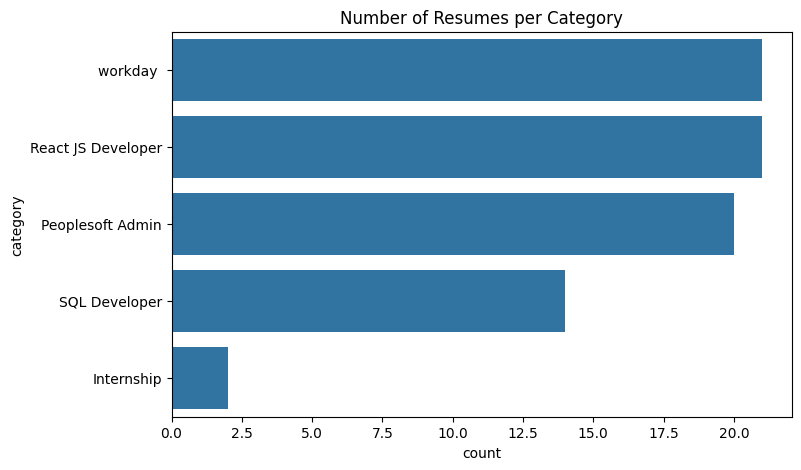

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    y=df['category'],
    order=df['category'].value_counts().index
)
plt.title("Number of Resumes per Category")
plt.show()


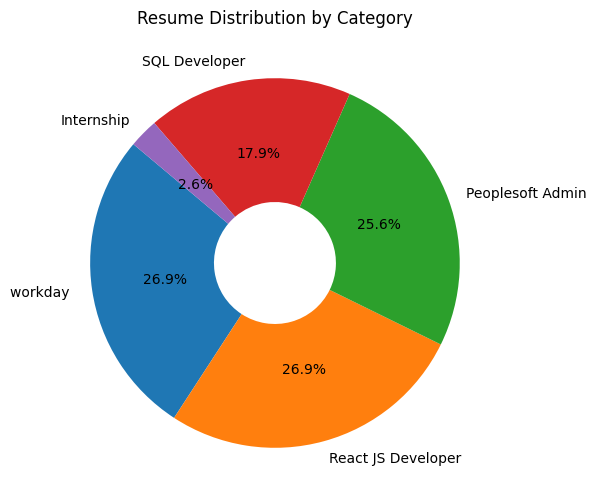

In [24]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.67)  # makes it donut
)

plt.title("Resume Distribution by Category")
plt.show()


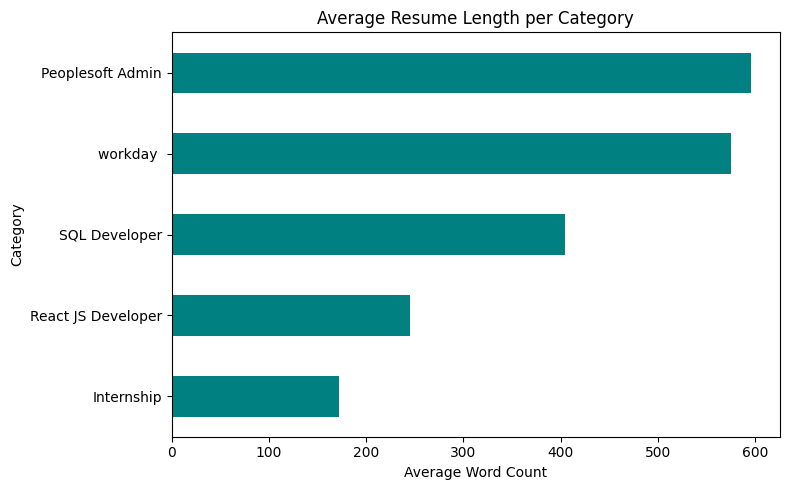

In [25]:
avg_length = df.groupby('category')['word_count'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_length.plot(kind='barh', color='teal')

plt.title("Average Resume Length per Category")
plt.xlabel("Average Word Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

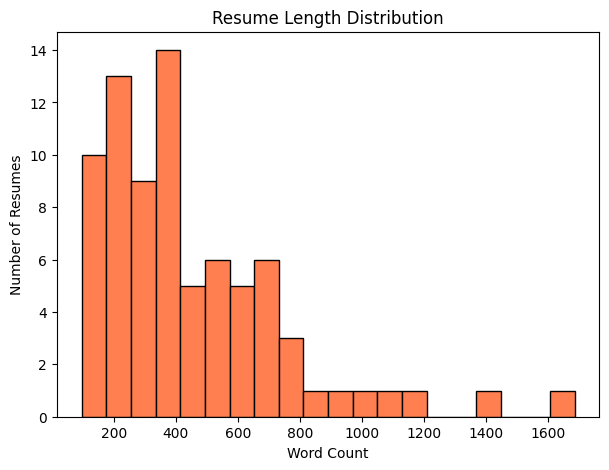

In [26]:
plt.figure(figsize=(7,5))
plt.hist(
    df['word_count'],
    bins=20,
    color='coral',
    edgecolor='black'
)

plt.title("Resume Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Resumes")
plt.show()

In [27]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_donut_for_category(df, category_name, top_n=10):
    # Combine all text for the category
    category_text = " ".join(
        df[df['category'] == category_name]['clean_text']
    )

    # Get top N words
    word_freq = Counter(category_text.split()).most_common(top_n)

    if not word_freq:
        print(f"No data for category: {category_name}")
        return

    words, counts = zip(*word_freq)

    # Plot donut chart
    plt.figure(figsize=(7,7))
    circle = plt.Circle((0, 0), 0.4, color='white')

    plt.pie(
        counts,
        labels=words,
        autopct='%1.1f%%',
        startangle=140
    )

    plt.gca().add_artist(circle)
    plt.title(f"Top {top_n} Words in {category_name} Resumes")
    plt.show()

In [28]:
df['category'].unique()

array(['workday ', 'SQL Developer', 'React JS Developer',
       'Peoplesoft Admin', 'Internship'], dtype=object)

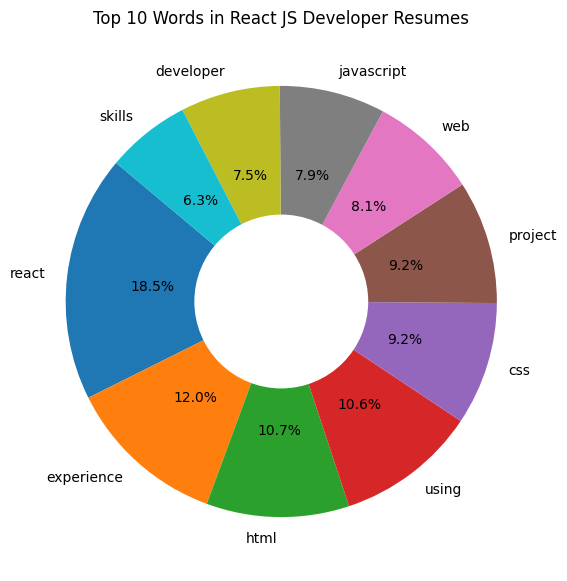

In [29]:
plot_donut_for_category(df, "React JS Developer")


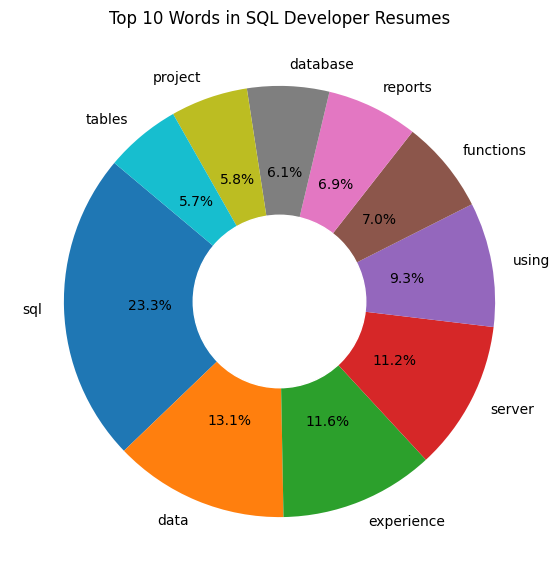

In [30]:
plot_donut_for_category(df, "SQL Developer")


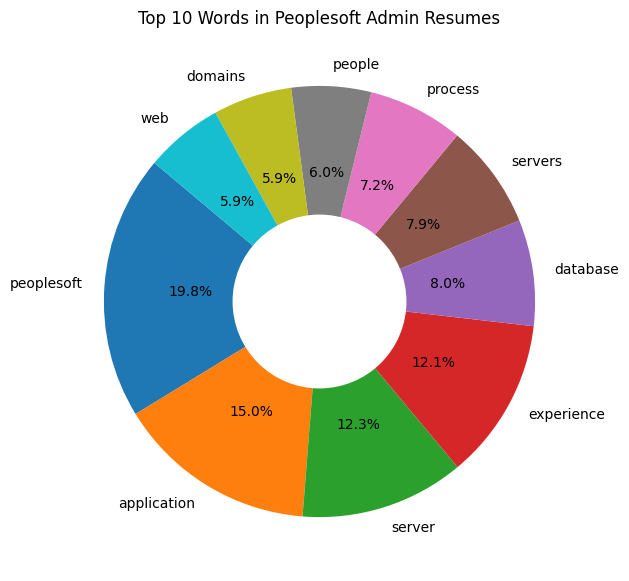

In [31]:
plot_donut_for_category(df, "Peoplesoft Admin")


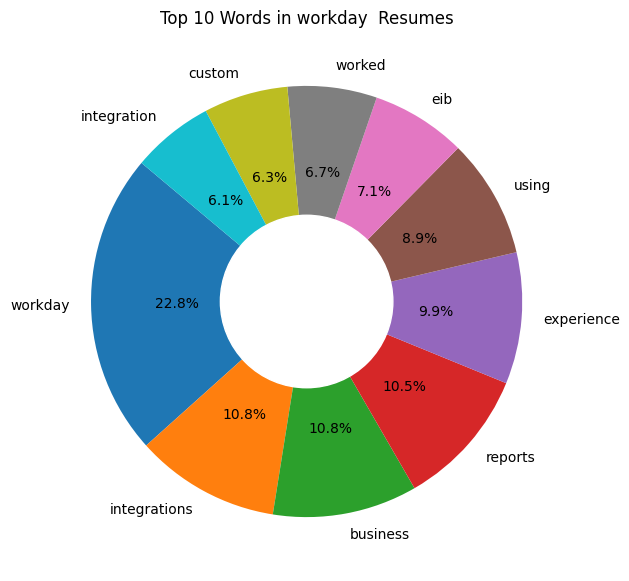

In [32]:
plot_donut_for_category(df, "workday ")


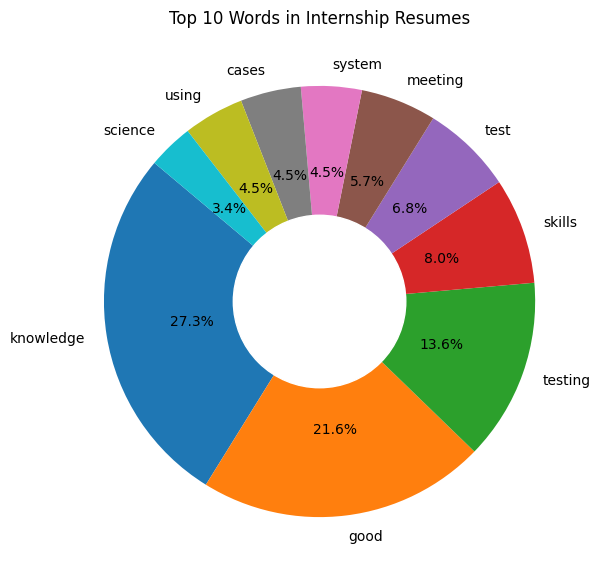

In [33]:
plot_donut_for_category(df, "Internship")


In [34]:
#Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_text']
y = df['category']

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

X_tfidf.shape


(78, 3000)

In [35]:
tfidf.get_feature_names_out()[:20]


array(['abilities', 'ability', 'ability work', 'absence',
       'absence management', 'academic', 'accenture', 'acceptance',
       'access', 'access people', 'according', 'account',
       'account provisioning', 'accounts', 'achieve', 'achievements',
       'across', 'across instances', 'active', 'activities'], dtype=object)

In [36]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (62, 3000)
Test shape: (16, 3000)


In [37]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9375

Classification Report (Logistic Regression):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
#Linear SVM
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (Linear SVM):\n")
print(classification_report(y_test, y_pred_svm))


Linear SVM Accuracy: 0.9375

Classification Report (Linear SVM):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9375

Classification Report (Random Forest):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))


Multinomial Naive Bayes Accuracy: 0.9375

Classification Report (Naive Bayes):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       1.00      1.00      1.00         4
     SQL Developer       1.00      1.00      1.00         3
          workday        0.80      1.00      0.89         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB()
cnb.fit(X_train, y_train)

y_pred_cnb = cnb.predict(X_test)

print("Complement Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("\nClassification Report (Complement NB):\n")
print(classification_report(y_test, y_pred_cnb))


Complement Naive Bayes Accuracy: 0.9375

Classification Report (Complement NB):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss="log_loss",   # logistic regression
    max_iter=1000,
    random_state=42
)

sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print("SGDClassifier Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("\nClassification Report (SGDClassifier):\n")
print(classification_report(y_test, y_pred_sgd))


SGDClassifier Accuracy: 0.9375

Classification Report (SGDClassifier):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       1.00      1.00      1.00         4
     SQL Developer       0.75      1.00      0.86         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.75      0.80      0.77        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("norm", Normalizer()),          # cosine-like normalization
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        metric="cosine"
    ))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report (KNN):\n")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9375

Classification Report (KNN):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       1.00      1.00      1.00         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      1.00      1.00         4

          accuracy                           0.94        16
         macro avg       0.76      0.80      0.78        16
      weighted avg       0.89      0.94      0.91        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels (XGBoost needs numbers)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train_enc)

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb)


print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.875

Classification Report (XGBoost):

                    precision    recall  f1-score   support

        Internship       0.00      0.00      0.00         1
  Peoplesoft Admin       0.80      1.00      0.89         4
React JS Developer       0.80      1.00      0.89         4
     SQL Developer       1.00      1.00      1.00         3
          workday        1.00      0.75      0.86         4

          accuracy                           0.88        16
         macro avg       0.72      0.75      0.73        16
      weighted avg       0.84      0.88      0.85        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted")
    }


In [46]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))
results.append(evaluate_model("Linear SVM", y_test, y_pred_svm))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("Multinomial NB", y_test, y_pred_nb))
results.append(evaluate_model("Complement NB", y_test, y_pred_cnb))
results.append(evaluate_model("SGDClassifier", y_test, y_pred_sgd))
results.append(evaluate_model("KNN", y_test, y_pred_knn))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

comparison_df = pd.DataFrame(results)
comparison_df


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.9375,0.777778,0.909722
1,Linear SVM,0.9375,0.777778,0.909722
2,Random Forest,0.9375,0.777778,0.909722
3,Multinomial NB,0.9375,0.777778,0.909722
4,Complement NB,0.9375,0.777778,0.909722
5,SGDClassifier,0.9375,0.771429,0.910714
6,KNN,0.9375,0.777778,0.909722
7,XGBoost,0.8750,0.726984,0.846230


In [47]:
comparison_df.sort_values(by="Macro F1", ascending=False)


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.9375,0.777778,0.909722
1,Linear SVM,0.9375,0.777778,0.909722
2,Random Forest,0.9375,0.777778,0.909722
3,Multinomial NB,0.9375,0.777778,0.909722
4,Complement NB,0.9375,0.777778,0.909722
6,KNN,0.9375,0.777778,0.909722
5,SGDClassifier,0.9375,0.771429,0.910714
7,XGBoost,0.8750,0.726984,0.846230


In [48]:
#Deployment

In [49]:
!pip install joblib


In [50]:
import joblib

joblib.dump(svm, "resume_classifier_svm.pkl")
print("Model saved as resume_classifier_svm.pkl")


Model saved as resume_classifier_svm.pkl


In [51]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("TF-IDF vectorizer saved as tfidf_vectorizer.pkl")


TF-IDF vectorizer saved as tfidf_vectorizer.pkl


In [52]:
joblib.dump(sorted(df['category'].unique()), "labels.pkl")
print("Labels saved")


Labels saved


In [53]:
svm_loaded = joblib.load("resume_classifier_svm.pkl")
tfidf_loaded = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully")


Model and vectorizer loaded successfully


In [54]:
import joblib

svm_model = joblib.load("resume_classifier_svm.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model & vectorizer loaded")


Model & vectorizer loaded


In [55]:
import pdfplumber
from docx import Document

def read_pdf(file_path):
    text = ""
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    return text

def read_docx(file_path):
    doc = Document(file_path)
    return " ".join([para.text for para in doc.paragraphs])


In [56]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Remove phone numbers
    text = re.sub(r'\b\d{10,12}\b', ' ', text)

    # 4. Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Remove stopwords (but keep important words)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
def predict_resume_category(file_path):
    # 1. Extract text
    if file_path.lower().endswith(".pdf"):
        text = read_pdf(file_path)
    elif file_path.lower().endswith(".docx"):
        text = read_docx(file_path)
    else:
        raise ValueError("Unsupported file format. Use PDF or DOCX.")

    if not text.strip():
        return "Could not extract text from resume"

    # 2. Clean text
    cleaned = clean_text(text)

    # 3. Vectorize
    vector = tfidf_vectorizer.transform([cleaned])

    # 4. Predict
    prediction = svm_model.predict(vector)[0]

    return prediction


In [58]:
test_resume_path = "/content/resumes/Resumes/React JS Developer/React Dev_Krishna Kanth.docx"
print("Predicted Category:", predict_resume_category(test_resume_path))


Predicted Category: React JS Developer


In [59]:
sample_files = [
    "/content/resumes/Resumes/Peoplesoft Admin/PeopleSoft DBA_Ganesh Alladi.docx",
    "/content/resumes/Resumes/SQL Developer/Anil kumar.docx",
]

for f in sample_files:
    print(f, "→", predict_resume_category(f))


/content/resumes/Resumes/Peoplesoft Admin/PeopleSoft DBA_Ganesh Alladi.docx → Peoplesoft Admin
/content/resumes/Resumes/SQL Developer/Anil kumar.docx → SQL Developer


In [60]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.9 MB/s eta 0:00:00


In [61]:
!pip install pdfplumber python-docx nltk scikit-learn joblib wordcloud matplotlib seaborn


In [62]:
!ngrok config add-authtoken 38T3HSZwHfYdjtIj0k2cZMSciSC_5bLT1L1guLfEZ14igxc4V


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [63]:
# !rm -f app.py


In [64]:
# !ls


In [78]:
%%writefile app.py
import streamlit as st
import joblib
import pdfplumber
from docx import Document
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import tempfile
import os

# ------------------ BASIC SETUP ------------------
st.set_page_config(page_title="Resume Classification", layout="centered")

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Load trained model & vectorizer
svm_model = joblib.load("resume_classifier_svm.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")

# ------------------ LABEL ALIAS (VERY IMPORTANT) ------------------
LABEL_ALIAS = {
    "react js developer": "react",
    "sql developer lightning insight": "sql",
    "peoplesoft admin": "peoplesoft",
    "peoplesoft resumes": "peoplesoft",
    "workday resumes": "workday",
    "internship": "internship"
}

# ------------------ SKILL DICTIONARY ------------------
SKILL_MAP = {
    "react": [
        "react", "javascript", "html", "css", "redux",
        "hooks", "bootstrap", "material ui",
        "rest api", "git", "webpack", "typescript"
    ],
    "sql": [
    "sql",
    "mysql",
    "postgresql",
    "oracle",
    "join", "joins",
    "index", "indexes",
    "stored", "procedure", "procedures",
    "function", "functions",
    "trigger", "triggers",
    "etl",
    "ssis",
    "cte",
    "subquery", "subqueries",
    "view", "views",
    "performance",
    "tuning"
    ],
    "peoplesoft": [
        "peoplesoft", "people tools", "peopletools",
        "hrms", "hcm", "finance", "payroll",
        "application engine", "app engine",
        "component", "record", "page",
        "sqr", "ps query", "bi publisher",
        "event mapping", "iws", "control m",
        "servicenow", "jira"
    ],
    "workday": [
        "workday", "hcm", "core hcm",
        "integration", "studio", "eib", "reporting"
    ],
    "internship": [
        "python", "java", "sql", "html",
        "css", "javascript", "data analysis"
    ]
}

# ------------------ HELPERS ------------------
def read_pdf(path):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    return text

def read_docx(path):
    doc = Document(path)
    return " ".join(p.text for p in doc.paragraphs)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{10,12}\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return " ".join(w for w in text.split() if w not in stop_words and len(w) > 2)

# ------------------ UI ------------------
st.title("📄 Resume Classification System")
st.write("Upload a resume (PDF or DOCX) to predict job role and extract key skills.")

uploaded_file = st.file_uploader("Upload Resume", type=["pdf", "docx"])

if uploaded_file is not None:

    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        tmp.write(uploaded_file.read())
        temp_path = tmp.name

    if uploaded_file.name.lower().endswith(".pdf"):
        raw_text = read_pdf(temp_path)
    else:
        raw_text = read_docx(temp_path)

    os.remove(temp_path)

    if raw_text.strip():

        cleaned_text = clean_text(raw_text)

        # -------- CATEGORY PREDICTION --------
        vector = tfidf_vectorizer.transform([cleaned_text])
        prediction = svm_model.predict(vector)[0]

        st.success(f" Predicted Category: **{prediction}**")

        # -------- TOP SKILLS DETECTED --------
        st.subheader(" Top Skills Detected")

        normalized_pred = prediction.lower().strip()
        role_key = LABEL_ALIAS.get(normalized_pred)

        detected_skills = []

        if role_key and role_key in SKILL_MAP:
            for skill in SKILL_MAP[role_key]:
                if re.search(r"\b" + re.escape(skill) + r"\b", cleaned_text):
                    detected_skills.append(skill)

        if detected_skills:
            st.write(", ".join(f"✔️ {s.title()}" for s in sorted(set(detected_skills))))
        else:
            st.warning("No key skills detected from predefined list.")

        # -------- WORD ANALYSIS --------
        st.subheader(" Top 10 Most Common Words")
        words = cleaned_text.split()
        freq = Counter(words).most_common(10)

        if freq:
            labels, counts = zip(*freq)
            fig, ax = plt.subplots()
            ax.barh(labels[::-1], counts[::-1])
            ax.set_xlabel("Frequency")
            st.pyplot(fig)

        # -------- WORD CLOUD --------
        st.subheader(" Word Cloud")
        wc = WordCloud(width=800, height=400, background_color="white").generate(cleaned_text)
        fig, ax = plt.subplots()
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        st.pyplot(fig)

        # -------- RAW TEXT --------
        with st.expander(" View Extracted Resume Text"):
            st.write(raw_text[:3000])


Overwriting app.py


In [66]:
# !ls


In [67]:

# !sed -n '1,20p' app.py


In [68]:
# !pkill -f streamlit

In [79]:
!streamlit run app.py --server.port 8501 --server.enableCORS false &>/content/logs.txt &


In [80]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(" App URL:", public_url)


 App URL: NgrokTunnel: "https://holistically-nonseditious-jan.ngrok-free.dev" -> "http://localhost:8501"
